### What is “Top‑K”?

- Top‑K means: Return K highest scoring documents based on similarity. Top‑K retrieval selects the K most relevant document chunks based on similarity scores and passes them to the LLM to generate grounded, accurate answers.

#### Example:

- If K = 3 → return top 3 most relevant chunks
- If K = 5 → return top 5
***It filters the search results to only the best one***

## How Top‑K works (Step-by-step)
### Step 1: Convert query to embedding

- Query → numerical vector

### Step 2: Compare with stored vectors

- Each document chunk already has an embedding
- System computes similarity (e.g., cosine similarity)

### Step 3: Rank documents

- Assign similarity score to each chunk
- Sort from highest → lowest relevance

### Step 4: Select Top‑K

- Take first K results
- Pass only those to LLM

***This ensures only the most relevant context is used***

### Example 1 (Very Simple – Conceptual)
- Query:👉 “What is Python used for?”
Suppose database has these chunks:

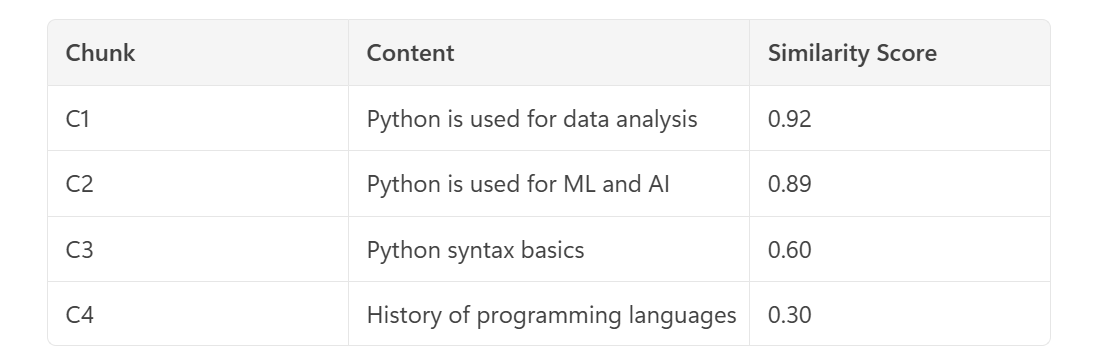

- If Top‑K = 2:
👉 Retrieved:C1 and C2

- If Top‑K = 3:
👉 Retrieved:C1, C2, C3

***These selected chunks go to LLM for answer generation***

### Example 2 (Real-world: Library analogy)

Think of a library search system:

- Query: “Books on space exploration”
- Each book has a similarity score
- System picks most relevant ones

***Similarity decides ranking***

***Top‑K decides how many books you take from shelf***

- Embedding = “convert text to numbers”
- Similarity = “how close meanings are”
- Top‑K = “keep only best K matches”

### RAG Demo: Top-K Retrieval using FAISS

This notebook demonstrates how **Retrieval-Augmented Generation (RAG)** works using:
- Embeddings (SentenceTransformers)
- FAISS (Vector Database)
- Top-K Retrieval

---



### Step 1: Install Libraries



### Step 2: Create Sample Documents


In [1]:

documents = [
    "Python is used for data analysis and machine learning.",
    "Dogs are loyal and friendly animals.",
    "Python is popular for AI and deep learning applications.",
    "Cats are independent pets.",
    "Machine learning helps build predictive models."
]

print(documents)


['Python is used for data analysis and machine learning.', 'Dogs are loyal and friendly animals.', 'Python is popular for AI and deep learning applications.', 'Cats are independent pets.', 'Machine learning helps build predictive models.']



### Step 3: Convert Documents to Embeddings


In [2]:

from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(documents)

print(doc_embeddings.shape)


C:\Users\Suyashi144893\AppData\Local\anaconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3741.90it/s]


(5, 384)



### Step 4: Store Embeddings in FAISS Index


In [3]:

import faiss

dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))

print("Number of documents in index:", index.ntotal)


Number of documents in index: 5



### Step 5: Query + Top-K Retrieval


In [4]:

query = "What is Python used for?"
query_embedding = model.encode([query])

K = 2  # Top-K

Distances, Indices = index.search(query_embedding, K)

print("Top-K Results:")
for i, idx in enumerate(Indices[0]):
    print(f"Rank {i+1}:", documents[idx])


Top-K Results:
Rank 1: Python is used for data analysis and machine learning.
Rank 2: Python is popular for AI and deep learning applications.



### Step 6: Try Different K Values

Change K to see how results differ.


In [5]:

K = 3
Distances, Indices = index.search(query_embedding, K)

print("Top-K=3 Results:")
for i, idx in enumerate(Indices[0]):
    print(f"Rank {i+1}:", documents[idx])


Top-K=3 Results:
Rank 1: Python is used for data analysis and machine learning.
Rank 2: Python is popular for AI and deep learning applications.
Rank 3: Machine learning helps build predictive models.



### Key Learning

- Top-K controls how many documents are retrieved
- Lower K → precise, faster
- Higher K → more coverage, but may include noise

---
